# Higer-Order Differential Equations and Systems of 1st-Order Differential Equations


In [1]:
# importing libraries
import numpy as np
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

# Definition of the IVP

In [2]:
# Define the IVP:

# Diff. Eqn.: y'' = f(x,y,y') = f(x,y0,y1)
# Define the IVP for Part (b)
def f(t, y):
    rhs = np.zeros((2, 1))
    # y[0] is y, y[1] is y'
    rhs[0] = y[1]
    rhs[1] = 2*y[1] - y[0] + t * (np.exp(t) - 1)
    return rhs

# Initial Condition
y0 = np.array([[-0.4],[-0.6]])

In [3]:
# Explicit Runge-Kutta 4th-order Method
def erk4(t, w, h):
    s1 = f(t, w)
    s2 = f(t + 0.5*h, w + 0.5*h*s1)
    s3 = f(t + 0.5*h, w + 0.5*h*s2)
    s4 = f(t + h, w + h*s3)

    phi = (1/6)*(s1 + 2*s2 + 2*s3 + s4)
    return phi

In [4]:
# Time-stepping method to solve Initial Value Problems (IVPs)
# Use with f(t,y) to evaluate rhs of differential equation
# Input: interval endoints a and b,
#        initial condition y0,
#        number of steps n,
#        time-stepping flag s,
#                           s = 1:  Euler
#                           s = 2:  Explicit Trapezoid Method
#                           s = 4:  Runge-Kutta 4th-order
#
# Output: time steps t, approximate solution w
# Usage: euler(a,b,y_0,n)
# Example: euler(0,1,1,10)
def tstep(a, b, y0, n, mthd):
    m = np.size(y0)
    t = np.zeros(n+1)
    w = np.zeros((m, n+1))
    h = (b-a)/n
    t[0] = a
    w[:, 0:1] = y0

    for i in range(1, n+1):
        t[i] = t[i-1] + h
        if mthd == 1: # Euler
            w[:, i:i+1] = w[:, i-1:i] + h * f(t[i-1], w[:, i-1:i])
        elif mthd == 2: # Explicit Trapezoid
            k1 = f(t[i-1], w[:, i-1:i])
            k2 = f(t[i], w[:, i-1:i] + h * k1)
            w[:, i:i+1] = w[:, i-1:i] + (h/2) * (k1 + k2)
        elif mthd == 4: # RK4
            w[:, i:i+1] = w[:, i-1:i] + h * erk4(t[i-1], w[:, i-1:i], h)
    return t, w


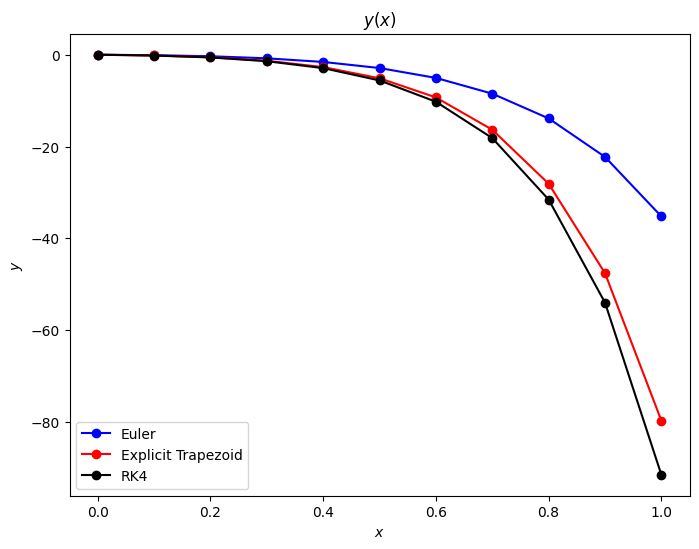

In [10]:
# Parameters
a, b = 0, 1
h = 0.1
n = int((b-a)/h)
y0_6 = np.array([[0.0], [0.0]]) # y(0)=0, y'(0)=0

# Exact solution function for comparison
#def exact_a(t):
   # y1 = (1/3)*(np.exp(5*t) - np.exp(-t)) + np.exp(2*t)
   # y2 = (1/3)*(np.exp(5*t) + 2*np.exp(-t)) + t**2 * np.exp(2*t)
   # return y1, y2

def exact_6a(t):
    return (1/6)*(t**3)*np.exp(t) - t*np.exp(t) + 2*np.exp(t) - t - 2

# Solve using your tstep function
[teu, weu] = tstep(a, b, y0_6, n, 1)
[ttr, wtr] = tstep(a, b, y0_6, n, 2)
[trk, wrk] = tstep(a, b, y0_6, n, 4)

# Calculate Exact and Errors
y_exact = exact_6a(trk)
err_eu = np.abs(y_exact - weu[0, :])
err_tr = np.abs(y_exact - wtr[0, :])
err_rk = np.abs(y_exact - wrk[0, :])

plt.figure(figsize=(8, 6))
plt.plot(teu,weu[0,:],'-o',color='blue',label = f'Euler')
plt.plot(ttr,wtr[0,:],'-o',color='red',label = f'Explicit Trapezoid')
plt.plot(trk,wrk[0,:],'-o',color='black',label = f'RK4')
plt.xlabel(f'$x$')
plt.ylabel(f'$y$')
plt.title(f'$y(x)$')

plt.legend();

In [11]:
import pandas as pd


# Calculate Exact and Errors
y_exact = exact_6a(trk)
err_eu = np.abs(y_exact - weu[0, :])
err_tr = np.abs(y_exact - wtr[0, :])
err_rk = np.abs(y_exact - wrk[0, :])

# --- Table Generation ---
y_ex = exact_6a(trk)

data = {
    'i': np.arange(n + 1),
    'ti': trk,
    'wi (RK4)': wrk[0, :],
    'y(ti)': y_ex,
    'Err Euler': np.abs(y_ex - weu[0, :]),
    'Err Trap': np.abs(y_ex - wtr[0, :]),
    'Err RK4': np.abs(y_ex - wrk[0, :])
}

df = pd.DataFrame(data)
pd.options.display.float_format = '{:.6e}'.format
print(df.to_string(index=False))

 i           ti      wi (RK4)        y(ti)    Err Euler     Err Trap      Err RK4
 0 0.000000e+00  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 1 1.000000e-01 -1.792075e-01 8.939497e-06 1.000089e-01 1.673005e-01 1.792165e-01
 2 2.000000e-01 -5.927668e-01 1.535017e-04 3.347366e-01 5.528304e-01 5.929204e-01
 3 3.000000e-01 -1.411333e+00 8.343375e-04 7.854917e-01 1.311275e+00 1.412167e+00
 4 4.000000e-01 -2.921068e+00 2.832313e-03 1.578322e+00 2.698819e+00 2.923901e+00
 5 5.000000e-01 -5.599552e+00 7.430266e-03 2.907203e+00 5.137446e+00 5.606982e+00
 6 6.000000e-01 -1.024113e+01 1.656260e-02 5.069012e+00 9.319604e+00 1.025769e+01
 7 7.000000e-01 -1.816385e+01 3.299805e-02 8.516233e+00 1.637850e+01 1.819685e+01
 8 8.000000e-01 -3.155087e+01 6.056194e-02 1.393630e+01 2.816509e+01 3.161143e+01
 9 9.000000e-01 -5.401374e+01 1.044052e-01 2.237102e+01 4.769850e+01 5.411815e+01
10 1.000000e+00 -9.152139e+01 1.713288e-01 3.539608e+01 7.989834e+01 9.169272e+01


# Boundary Value Problems (BVP)
## The Linear Shooting Method

In [ ]:
# Apporximation solution using RK4
# parameters specific to current BVP
a     =
b     =
n     =

# Boundary Conditions:
alpha =
beta  =

# Initial Condition
yp0 = np.array([[],[]])

# Solve Nonhomogenous problem
[t,wp]  = tstep(a,b,yp0,n,4)

In [ ]:
# Initial Condition
yh0 = np.array([[],[]])

# Solve homogeneous IVP
[t,wh] = tstep(a,b,yh0,n,4)

In [ ]:
# Form linear combination of nonhomogeneous and homogeneous solution
s = (beta - wp[0,-1])/wh[0,-1]

w = wp + s*wh

y_exact =


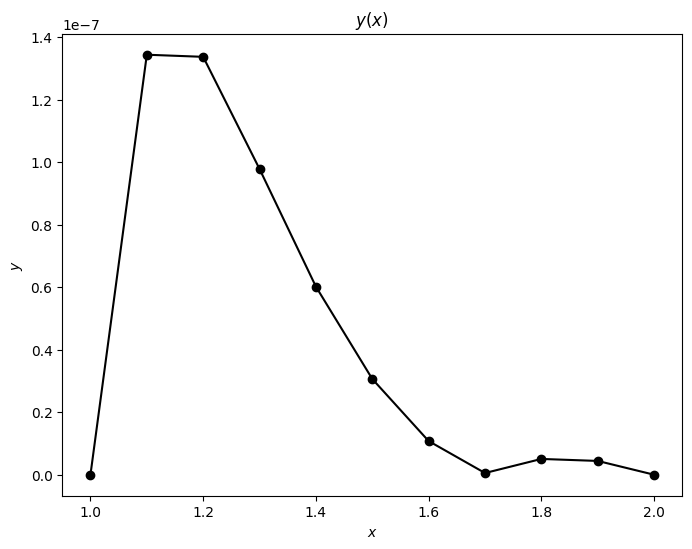

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(t,np.abs(y_exact - w[0,:]),'-o',color='black',label = f'RK4')
plt.xlabel(f'$x$')
plt.ylabel(f'$y$')
plt.title(f'$y(x)$');